## CPSC 390 Spring 26 Project 2 - Genetic Algorithm
Name: Dennis Fomichev

### Constant variables for the genetic algorithm
This is where the main parameters for the genetic algorithm are defined, it has the target (what we want to reach), the population size (how many strings to generate), and also the mutation rate (how often mutations should occur, should be a low number). I also included a variable to set the max number of generations that the algorithm can do, just in case there is a possible target that will take a super long time to generate. Finally, there's also the range of what values we want represented in the string, in this case it is ' ' to 'z', which I changed into the direct ASCII values.

In [300]:
import random
import matplotlib.pyplot as plt

# The main genetic algorithm changable variables
TARGET = "Hello CPSC 390!" # What the final output (the goal) should be
POP_SIZE = 128 # The size of the population
MUTATION_RATE = 0.1 # The rate at which the mutation occurs
GENERATIONS = 1000 # The max number of generations that could possibly run before the algorithm terminates

# The ASCII value range for possilbe characters in the string (looked their up corresponding values via ASCII table online)
ASCII_MIN = 32 # Represents ' '
ASCII_MAX = 122 # Represents 'z'

### Main genetic algorithm implementation
The following functions hold the primary logic for this genetic algorithm, since they are responsible for creating the individuals themselves, then forming the entire populations, along with determing their fitness, then also doing crossovers via parent selections and random mutations.

In [301]:
# Generates a random character ASCII value, then converts it to a char
def GenerateRandomCharacter():
    return chr(random.randint(ASCII_MIN, ASCII_MAX))

# Creates an individual string of random characters based on the target's length
def CreateIndividual():
    individual = ""

    # Create all of the random characters
    for i in range(len(TARGET)):
        individual += GenerateRandomCharacter()

    return individual

# Used in the actual main loop, creates the initial population based on the population size
def CreatePopulation():
    population = []

    # Create all of the random individuals
    for i in range(POP_SIZE):
        population.append(CreateIndividual())

    return population

# Determines the fitness (how close it is to the target based on the character indexes) of an individual string
def Fitness(individual):
    fitness = 0

    # Compare each character in the new string to the target
    for i in range(len(TARGET)):
        if individual[i] == TARGET[i]:
            fitness += 1

    return fitness

# Selects the best parents (highest fitness) from the population to be used for crossovers
def Selection(population):
    # Sort population by fitness in descending order
    sortedPopulation = sorted(population, key=Fitness, reverse=True)

    # Select the top two fittest individuals as parents
    parent1 = sortedPopulation[0]
    parent2 = sortedPopulation[1]

    return parent1, parent2

# Perform crossover between two parents by comibing them to get a new child
def Crossover(parent1, parent2):
    crossoverPoint = random.randint(1, len(parent1) - 1) # Select a random index to split the parents
    child = parent1[:crossoverPoint] + parent2[crossoverPoint:] # Combine the parents at their respective split points

    return child

# Mutates an individual string by randomly changing its characters based on the mutation rate
def Mutation(individual):
    newIndividual = ""

    # Go through each character, see if we can randomly change it or keep it the same
    for char in individual:
        if random.random() < MUTATION_RATE:
            newIndividual += GenerateRandomCharacter()
        else:
            newIndividual += char

    return newIndividual

### Main generation loop
This main loop handles tracking each generation of the genetic process. It determines the current state by finding the best fitness individual in the current population, then choosing it as the main one to use for future generations. It performs crossover by selecting 2 parents, and then also applies random mutations, getting us closer to the target each generation. The output is one of the main aspects of this project, since we can see the status of the algorithm every 10 generations and when exactly it finish and they match.

In [302]:
def MainLoop():
    # Create the initial population and a way to keep track of fitness overtime (for plotting purposes)
    population = CreatePopulation()
    bestFitnessHistory = []

    # Run each generation until we reach target
    for generation in range(GENERATIONS):
        # Determine the best fitness individual, add it to the history array
        best = max(population, key=Fitness)
        bestFit = Fitness(best)
        bestFitnessHistory.append(bestFit)

        # Print out what we have every 10 generations
        if generation % 10 == 0:
            print(f"Generation {generation} | \"{best}\" w/ {bestFit} fitness")

        # If our current generation is the same as desired target, then we're done!
        if best == TARGET:
            print(f"Generation {generation} | \"{best}\" w/ {bestFit} fitness")
            break
        
        newPopulation = []

        # Create a new population to be used for the next generation, do crossover and random mutation for new children
        while len(newPopulation) < POP_SIZE:
            parent1, parent2 = Selection(population)

            child = Crossover(parent1, parent2)
            child = Mutation(child)

            newPopulation.append(child)

        population = newPopulation
    
    return bestFitnessHistory

In [303]:
bestFitnessHistory = MainLoop()

Generation 0 | "!DaJQvC;3*>aS1!" w/ 2 fitness
Generation 10 | "bDalo C;Sc [9=U" w/ 7 fitness
Generation 20 | "HGllo CPSC E9!!" w/ 12 fitness
Generation 30 | "HKllo CPSC 39SZ" w/ 12 fitness
Generation 40 | "HHllo CPSC 390J" w/ 13 fitness
Generation 50 | "HHllo CPSC 390J" w/ 13 fitness
Generation 60 | "H%llo CPSC 390F" w/ 13 fitness
Generation 70 | "Hello CPSC 390_" w/ 14 fitness
Generation 72 | "Hello CPSC 390!" w/ 15 fitness


### Fitness score plot
Compares the best fitness of each generation. Uses a log scale on the horiziontal access to display the generation and the actual fitness score on the y axis.

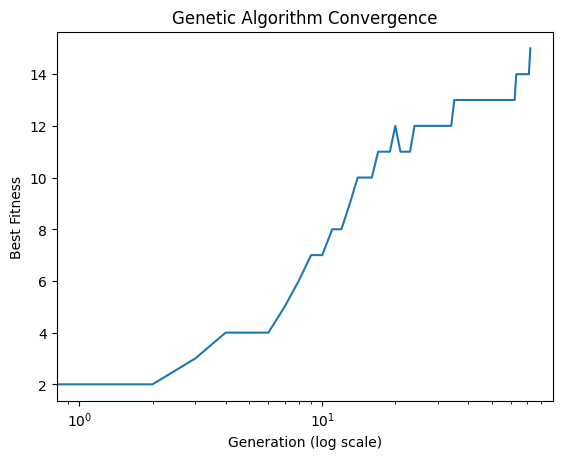

In [304]:
plt.figure()
plt.plot(range(len(bestFitnessHistory)), bestFitnessHistory)
plt.xscale("log")
plt.xlabel("Generation (log scale)")
plt.ylabel("Best Fitness")
plt.title("Genetic Algorithm Convergence")
plt.show()

### Discussion: effectiveness of this implementation
Generally speaking, the algorithm does a good job of gradually improving fitness overtime. This is because in each generation, correct characters are usually kept once they are found in the fitness, then there's also the crossover process, which selects the 2 best parents and makes a (hopefully) better child. Finally, there's also the random mutations, which I think have a pretty big effect on this specific implementation actually. I tried playing around with only changing the mutation rate value in the constants section, ranging from 0.01 (1%) to 0.2 (10%), and I found that around 0.1 it gave the best output, meaning it had the least generations. I generally found that when I kept it sligtly below or above 0.1, it would get the target value after 100-200 generations, whereas with 0.1 it can do usually under 100, sometimes above 100, but closer to the 100 range than 200.

I believe there are a couple of things that make this algorithm a bit inefficent though. First, there is no elitism (something that I can implement), meaning that the best solution can be sometimes lost in the next generation, depending on the random mutations or crossovers. Also, the fitness landscape can be sparse, since many mutations will produce no improvement and only the exact character matches will lead to a better fitness. Related to the no elitism as well, there could be crossovers that lead to a good parent being broken up and lost.

The best improvement that can be made in this context is implementing elitism, so that the 1-2 best individuals from the current generation are always copied into the next one, making sure that we never lose our best individuals and lose progress.

### EXTRA CREDIT: Main generation loop (with Elitism)
Pretty much the same as the original generation loop, except I changed the newPopulation array declaration to always include the best individual.

In [305]:
def MainLoopElitism():
    # Create the initial population and a way to keep track of fitness overtime (for plotting purposes)
    population = CreatePopulation()
    bestEliteFitnessHistory = []

    # Run each generation until we reach target
    for generation in range(GENERATIONS):
        # Determine the best fitness individual, add it to the history array
        best = max(population, key=Fitness)
        bestFit = Fitness(best)
        bestEliteFitnessHistory.append(bestFit)

        # Print out what we have every 10 generations
        if generation % 10 == 0:
            print(f"Generation {generation} | \"{best}\" w/ {bestFit} fitness")

        # If our current generation is the same as desired target, then we're done!
        if best == TARGET:
            print(f"Generation {generation} | \"{best}\" w/ {bestFit} fitness")
            break
        
        newPopulation = [best] # ELITISM

        # Create a new population to be used for the next generation, do crossover and random mutation for new children
        while len(newPopulation) < POP_SIZE:
            parent1, parent2 = Selection(population)

            child = Crossover(parent1, parent2)
            child = Mutation(child)

            newPopulation.append(child)

        population = newPopulation

    return bestEliteFitnessHistory

In [306]:
bestEliteFitnessHistory = MainLoopElitism()

Generation 0 | "HeH._0IbkmMf9V)" w/ 3 fitness
Generation 10 | "HeHlol<Pq3R3W@H" w/ 6 fitness
Generation 20 | "HeHlo UPGCR390h" w/ 10 fitness
Generation 30 | "HeHlo CPSCl3901" w/ 12 fitness
Generation 40 | "HeHlo CPSCl3901" w/ 12 fitness
Generation 50 | "HeHlo CPSC 390o" w/ 13 fitness
Generation 60 | "HeHlo CPSC 390o" w/ 13 fitness
Generation 70 | "HeHlo CPSC 390!" w/ 14 fitness
Generation 80 | "HeHlo CPSC 390!" w/ 14 fitness
Generation 90 | "HeHlo CPSC 390!" w/ 14 fitness
Generation 100 | "HeHlo CPSC 390!" w/ 14 fitness
Generation 102 | "Hello CPSC 390!" w/ 15 fitness


### Fitness score plot (Elitism)
Compares the best fitness of each generation. Uses a log scale on the horiziontal access to display the generation and the actual fitness score on the y axis.

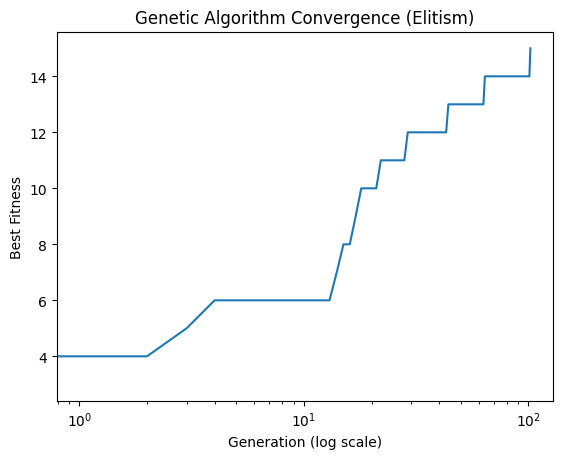

In [307]:
plt.figure()
plt.plot(range(len(bestEliteFitnessHistory)), bestEliteFitnessHistory)
plt.xscale("log")
plt.xlabel("Generation (log scale)")
plt.ylabel("Best Fitness")
plt.title("Genetic Algorithm Convergence (Elitism)")
plt.show()

### Performance improvements over 32 iterations
NOTE: I had to go back into both code sections (for non-elitism and elitism) and wrap them in functions so that I can call them 32 times to track their performance. Then, I had to change the code so it returned the array of best fitness individuals, so that the previous code with graph generation could still work. Also, this section of code can take a while to run...

Generation 0 | " e0lsJ>f8nf0YlZ" w/ 2 fitness
Generation 10 | " ellssC4SC7R90F" w/ 8 fitness
Generation 20 | "Hello C[SCru90%" w/ 11 fitness
Generation 30 | "Hello CPSCC390!" w/ 14 fitness
Generation 40 | "Hello CPSC3390!" w/ 14 fitness
Generation 50 | "Hello CPSC,390!" w/ 14 fitness
Generation 60 | "Hello CPSC,390!" w/ 14 fitness
Generation 70 | "Hello CPSCW390!" w/ 14 fitness
Generation 80 | "Hello CPSCr390!" w/ 14 fitness
Generation 90 | "Hello CPSCd390!" w/ 14 fitness
Generation 100 | "Hello CPSC`390!" w/ 14 fitness
Generation 110 | "Hello CPSCX390!" w/ 14 fitness
Generation 120 | "Hello CPSC-390!" w/ 14 fitness
Generation 127 | "Hello CPSC 390!" w/ 15 fitness
Generation 0 | "u:3l4XHgL-YT#S!" w/ 2 fitness
Generation 10 | "G:3lo]C3>"n3Y0!" w/ 6 fitness
Generation 20 | "H?:lo]CP)" 3Y0!" w/ 9 fitness
Generation 30 | "Hqylo CP C 3Y0!" w/ 11 fitness
Generation 40 | "H>llo CPSC 390!" w/ 14 fitness
Generation 50 | "HLllo CPSC 390!" w/ 14 fitness
Generation 60 | "Hrllo CPSC 390!" w/ 14 fit

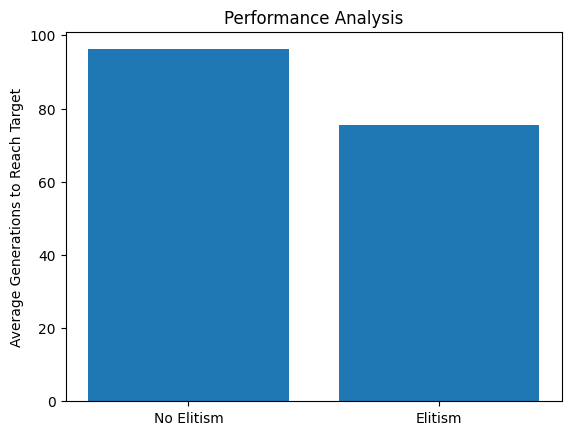

In [308]:
# Storing the number of generations for each iteration
numGenerationsNon = []
numGenerationsElite = []

# Run the non-elite version 32 times, add the generation count of each iteration to array
for i in range(32):
    generation = MainLoop()
    numGenerationsNon.append(len(generation))

# Run the elite version 32 times, add the generation count of each iteration to array
for i in range(32):
    generation = MainLoopElitism()
    numGenerationsElite.append(len(generation))

# Find the averages of each
avgNon = sum(numGenerationsNon) / len(numGenerationsNon)
avgElite = sum(numGenerationsElite) / len(numGenerationsElite)

# Print the averages of both
print(f"Average generations (No Elitism): {avgNon}")
print(f"Average generations (Elitism): {avgElite}")

# Print the best/worst run of no elitism
print(f"Best run (No Elitism): {min(numGenerationsNon)}")
print(f"Worst run (No Elitism): {max(numGenerationsNon)}")

# Print the best/worst run of elitism
print(f"Best run (Elitism): {min(numGenerationsElite)}")
print(f"Worst run (Elitism): {max(numGenerationsElite)}")

# % Analysis
print(f"Elitism is {(((avgNon - avgElite) / avgElite) * 100):.2f}% better than the non version.")

# Generate a graph to show some results
plt.figure()
plt.bar(["No Elitism", "Elitism"], [avgNon, avgElite])
plt.ylabel("Average Generations to Reach Target")
plt.title("Performance Analysis")
plt.show()
